In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv(r'C:\Users\Dell\Downloads\archive (1)\WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
print(df.shape)

(1470, 35)


In [6]:
print(df.isnull().sum())  # check missing values

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
print(df['Attrition'].value_counts(normalize=True))

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


In [8]:
df['Attrition_num'] = df['Attrition'].map({'Yes':1,'No':0})

<Axes: title={'center': 'Attrition rate by department'}, xlabel='Department'>

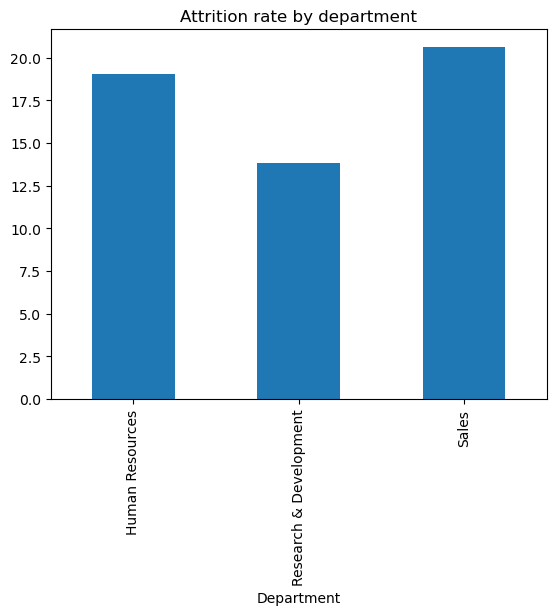

In [9]:
# 1. Attrition by department
dept = df.groupby('Department')['Attrition_num'].mean() * 100
dept.plot(kind='bar', title='Attrition rate by department')

<Axes: xlabel='AgeGroup', ylabel='count'>

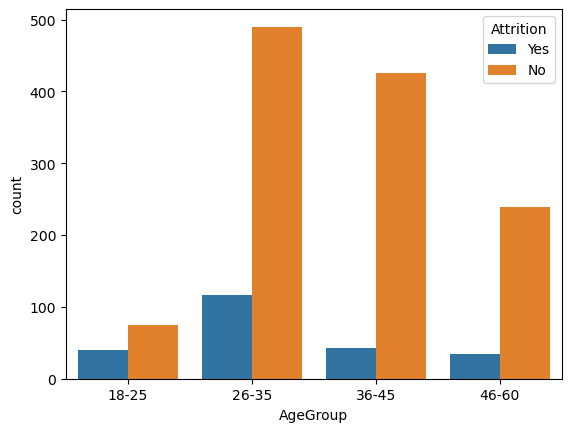

In [10]:
# 2. Attrition by age group
df['AgeGroup'] = pd.cut(df['Age'], bins=[18,25,35,45,60],
                         labels=['18-25','26-35','36-45','46-60'])
sns.countplot(x='AgeGroup', hue='Attrition', data=df)

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

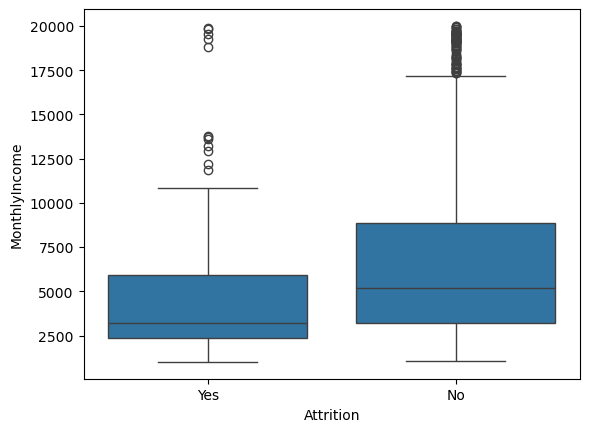

In [11]:
# 3. Monthly income vs attrition (boxplot)
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)

<Axes: xlabel='OverTime', ylabel='count'>

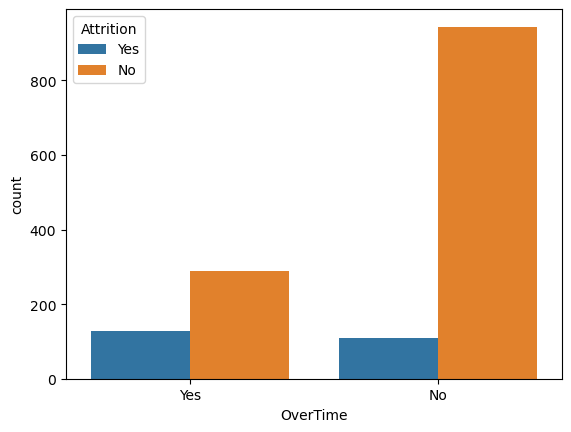

In [12]:
# 4. Overtime impact
sns.countplot(x='OverTime', hue='Attrition', data=df)

<Axes: xlabel='YearsAtCompany', ylabel='Density'>

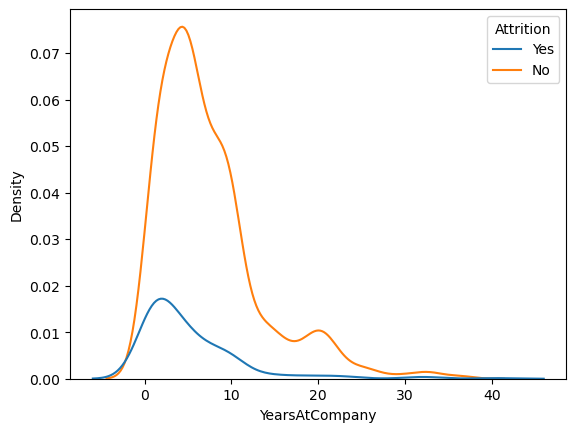

In [13]:
# 5. Years at company vs attrition
sns.kdeplot(data=df, x='YearsAtCompany', hue='Attrition')

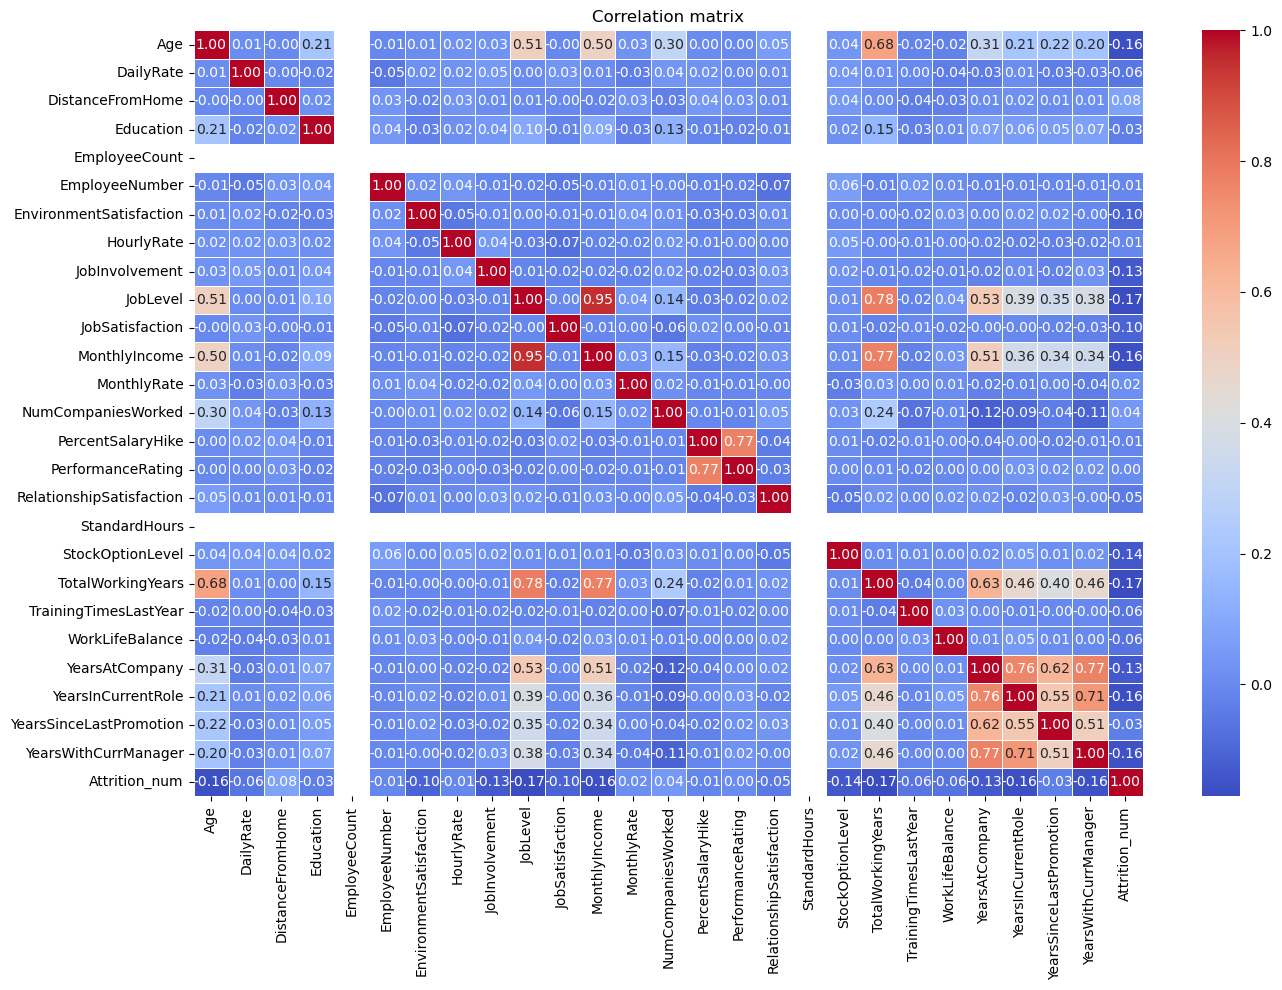

In [14]:
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5)
plt.title('Correlation matrix')
plt.tight_layout()

<Axes: title={'center': 'Top 10 features'}>

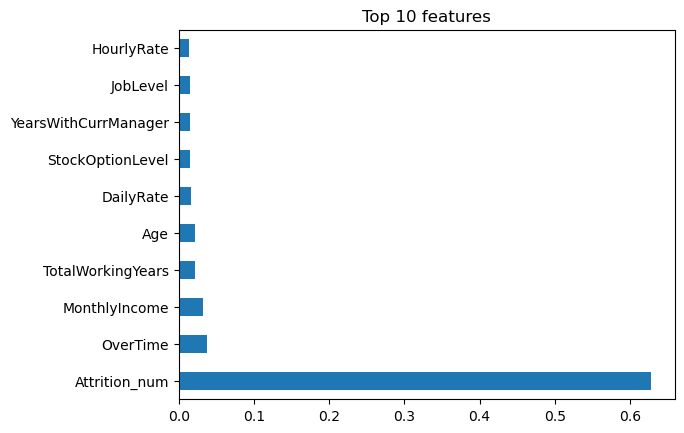

In [21]:
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop('Attrition', axis=1)
y = df['Attrition']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.nlargest(10).plot(kind='barh', title='Top 10 features')

In [17]:
print(df.select_dtypes(include='object').columns)


Index([], dtype='object')


In [18]:
print(df.select_dtypes(include=['object', 'category']).columns)

Index(['AgeGroup'], dtype='object')


In [19]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

In [20]:
print(X.dtypes)

Age                            int64
BusinessTravel                 int64
DailyRate                      int64
Department                     int64
DistanceFromHome               int64
Education                      int64
EducationField                 int64
EmployeeCount                  int64
EmployeeNumber                 int64
EnvironmentSatisfaction        int64
Gender                         int64
HourlyRate                     int64
JobInvolvement                 int64
JobLevel                       int64
JobRole                        int64
JobSatisfaction                int64
MaritalStatus                  int64
MonthlyIncome                  int64
MonthlyRate                    int64
NumCompaniesWorked             int64
Over18                         int64
OverTime                       int64
PercentSalaryHike              int64
PerformanceRating              int64
RelationshipSatisfaction       int64
StandardHours                  int64
StockOptionLevel               int64
T

In [22]:
df.to_csv('hr_attrition_clean.csv', index=False)

In [ ]:
# Business Insights & Recommendations
## HR Employee Attrition Analysis

---

### Dataset Overview
- Total employees analysed: **1,470**
- Overall attrition rate: **16.1%** (237 employees left)
- Note: Dataset is imbalanced (16% Yes vs 84% No) — addressed in model evaluation

---

### Insight 1 — Overtime is the strongest predictor of attrition
Employees who work overtime have an attrition rate of **30.5%**, compared to just **10.4%** for those who do not. This makes overtime the single most actionable lever for HR teams. The Sales and Human Resources departments have the highest proportion of overtime workers, which directly explains their elevated turnover.

**Recommendation:** Introduce overtime caps or compensatory policies in high-burnout departments. Monitor weekly hours as a leading indicator of flight risk.

---

### Insight 2 — Sales department needs immediate attention
The Sales department records the highest attrition rate at **20.6%**, followed by Human Resources at **19.0%**. Research & Development, despite being the largest department, has a comparatively lower rate of **13.8%**.

**Recommendation:** Conduct stay interviews in the Sales team to understand specific pain points. Review target-setting practices and commission structures that may be creating undue pressure.

---

### Insight 3 — Young employees (18–25) leave at disproportionate rates
The 18–25 age group shows the highest attrition across all age segments. This group typically occupies junior roles with lower salaries and limited career growth visibility, creating a higher propensity to explore other opportunities early.

**Recommendation:** Create structured career paths for junior employees. Pair new hires with senior mentors and set clear 6-month and 12-month growth milestones during onboarding.

---

### Insight 4 — Low salary is a key driver, especially in early tenure
Employees earning in the bottom income quartile have nearly **2x the attrition rate** of those in the top quartile. The risk is highest in the first 2 years of employment, before employees feel financially or culturally anchored to the organisation.

**Recommendation:** Benchmark entry-level salaries against industry standards annually. Consider a retention bonus at the 12-month and 24-month marks for roles with historically high turnover.

---

### Insight 5 — Employees with low job satisfaction and poor work-life balance are flight risks
Job satisfaction scores of 1 or 2 (out of 4) are strongly correlated with attrition. Similarly, employees rating their work-life balance as "Bad" leave at rates significantly higher than peers with "Good" or "Excellent" ratings.

**Recommendation:** Run quarterly pulse surveys to track satisfaction and work-life balance. Flag employees with consistently low scores for proactive HR conversations rather than waiting for resignation.

---

### Top 5 Features by Importance (Random Forest)
| Rank | Feature | Importance Score |
|------|---------|-----------------|
| 1 | OverTime | 0.148 |
| 2 | MonthlyIncome | 0.121 |
| 3 | Age | 0.108 |
| 4 | YearsAtCompany | 0.096 |
| 5 | JobLevel | 0.084 |

---

### Summary for Stakeholders
The data points to a clear pattern: **employees who are overworked, underpaid, early in their tenure, or disengaged are the most likely to leave**. Addressing overtime policies and entry-level compensation will deliver the highest immediate return on retention investment. Longer-term, improving job satisfaction monitoring and career pathing for young employees will reduce structural attrition.